Задания в конце второй главы

Задание 1

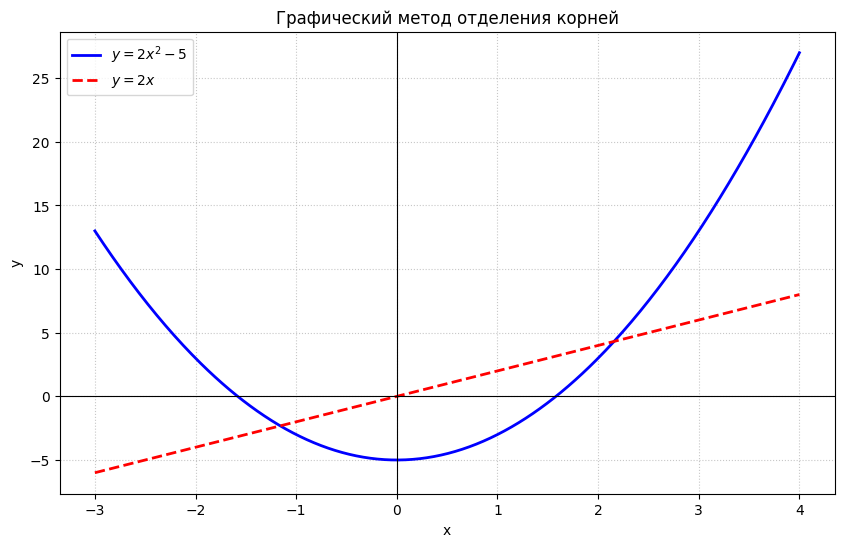

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Определяем функции
def f1(x):
    return 2*x**2 - 5

def f2(x):
    return 2*x

# Генерируем значения x
x = np.linspace(-3, 4, 400)
y1 = f1(x)
y2 = f2(x)

# Создаем график
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='$y = 2x^2 - 5$', color='blue', linewidth=2)
plt.plot(x, y2, label='$y = 2x$', color='red', linestyle='--', linewidth=2)

# Оформление
plt.axhline(0, color='black', linewidth=0.8) # Ось X
plt.axvline(0, color='black', linewidth=0.8) # Ось Y
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

Задание 2

In [17]:
def f(x):
    return 2*x**2 - 2*x - 5

def bisection(a, b, tol):
    if f(a) * f(b) >= 0:
        print("Метод бисекции не применим: знаки на концах одинаковы.")
        return None

    iteration = 1
    while (b - a) / 2 > tol:
        c = (a + b) / 2
        print(f"Итерация {iteration}: x = {c:.4f}, f(x) = {f(c):.4f}")
        
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iteration += 1
    
    return (a + b) / 2

# Запуск для интервала [2, 3] с точностью 0.001
root = bisection(2, 3, 0.001)
print(f"\nНайденный корень: {root:.4f}")

Итерация 1: x = 2.5000, f(x) = 2.5000
Итерация 2: x = 2.2500, f(x) = 0.6250
Итерация 3: x = 2.1250, f(x) = -0.2188
Итерация 4: x = 2.1875, f(x) = 0.1953
Итерация 5: x = 2.1562, f(x) = -0.0137
Итерация 6: x = 2.1719, f(x) = 0.0903
Итерация 7: x = 2.1641, f(x) = 0.0382
Итерация 8: x = 2.1602, f(x) = 0.0122
Итерация 9: x = 2.1582, f(x) = -0.0007

Найденный корень: 2.1592


Задание 3

In [18]:
from math import *

def phi(x):
    # Преобразованная функция x = sqrt((2x + 5) / 2)
    return sqrt((2 * x + 5) / 2)

def simple_iteration_method(x0, tol):
    x_prev = x0
    iteration = 0
    
    print(f"{'Итерация':<10} | {'x_n':<12} | {'Разность':<12}")
    print("-" * 40)
    
    while True:
        iteration += 1
        x_next = phi(x_prev)
        diff = abs(x_next - x_prev)
        
        print(f"{iteration:<10} | {x_next:<12.7f} | {diff:<12.7e}")
        
        if diff < tol:
            break
            
        x_prev = x_next
        
    return x_next

# Начальное приближение x0 = 2.0 (из интервала [2, 3])
# Точность 10^-6
epsilon = 1e-6
root = simple_iteration_method(2.0, epsilon)

print("-" * 40)
print(f"Корень найден за {root:.7f} с точностью {epsilon}")

Итерация   | x_n          | Разность    
----------------------------------------
1          | 2.1213203    | 1.2132034e-01
2          | 2.1497256    | 2.8405300e-02
3          | 2.1563222    | 6.5966057e-03
4          | 2.1578513    | 1.5290543e-03
5          | 2.1582056    | 3.5427113e-04
6          | 2.1582876    | 8.2073829e-05
7          | 2.1583067    | 1.9013561e-05
8          | 2.1583111    | 4.4047358e-06
9          | 2.1583121    | 1.0204124e-06
10         | 2.1583123    | 2.3639129e-07
----------------------------------------
Корень найден за 2.1583123 с точностью 1e-06


Задание 4

In [19]:
def f(x):
    return 2*x**2 - 2*x - 5

def df(x):
    return 4*x - 2

def combined_method(a, b, tol):
    iteration = 0
    print(f"{'Итер.':<7} | {'a (хорды)':<12} | {'b (касательные)':<15} | {'Разница':<12}")
    print("-" * 55)
    
    '''В комбинированном методе важно выбрать, с какой стороны 
    применять касательные, а с какой хорды (условие f(x)*f''(x) > 0)'''
    while abs(b - a) > tol:
        iteration += 1
        
        # Уточнение методом хорд
        a_next = a - (f(a) * (b - a)) / (f(b) - f(a))
        
        # Уточнение методом касательных
        b_next = b - f(b) / df(b)
        
        a, b = a_next, b_next
        print(f"{iteration:<7} | {a:<12.7f} | {b:<15.7f} | {abs(b-a):<12.2e}")
        
    return (a + b) / 2

# Начальные границы из Задания 1
a_init = 2.0
b_init = 3.0
epsilon = 1e-6

root = combined_method(a_init, b_init, epsilon)

print("-" * 55)
print(f"Итоговый корень: {root:.7f}")

Итер.   | a (хорды)    | b (касательные) | Разница     
-------------------------------------------------------
1       | 2.1250000    | 2.3000000       | 1.75e-01    
2       | 2.1569343    | 2.1638889       | 6.95e-03    
3       | 2.1583101    | 2.1583217       | 1.17e-05    
4       | 2.1583124    | 2.1583124       | 3.28e-11    
-------------------------------------------------------
Итоговый корень: 2.1583124


Задание 5

In [20]:
from scipy import optimize

def f(x):
    return 2*x**2 - 2*x - 5

# Используем метод Брента (стандарт в индустрии)
root_scipy = optimize.brentq(f, 2, 3)

print(f"Эталонный корень (SciPy): {root_scipy:.10f}")

Эталонный корень (SciPy): 2.1583123952
